In [2]:
from datasets import load_dataset

# 6.43B rows; streaming is strongly recommended
fwd = load_dataset("Salesforce/fineweb_deduplicated", streaming=True)

Resolving data files:   0%|          | 0/8801 [00:00<?, ?it/s]

## Exploratory Analysis

In [3]:
# Peek at the first record to see available fields
sample = next(iter(fwd["train"]))
print("Fields:", list(sample.keys()))
print()
for k, v in sample.items():
    preview = str(v)[:200] + "..." if len(str(v)) > 200 else str(v)
    print(f"  {k}: {preview}")

Fields: ['row_count', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'token_count', 'text']

  row_count: 1
  id: <urn:uuid:ba044688-f2b2-412f-949e-019cd39b84cc>
  dump: CC-MAIN-2014-10
  url: http://www.actionnewsjax.com/sports/nba/story/NBA-to-play-regular-season-games-in-Mexico-City/ra_nvJ-8dEW6UFYwO06Fmg.cspx
  date: 2014-03-17T01:49:07Z
  file_path: s3://commoncrawl/crawl-data/CC-MAIN-2014-10/segments/1394678704396/warc/CC-MAIN-20140313024504-00017-ip-10-183-142-35.ec2.internal.warc.gz
  language: en
  language_score: 0.9344997406005859
  token_count: 193
  text: New York, NY (Sports Network) - The NBA will stage games in Mexico City and London during the 2013-14 season.
The NBA announced Tuesday that the Minnesota Timberwolves and San Antonio Spurs will play ...


Sampled 5000 records


/var/folders/t4/gn3h1ztn34zdb3_pr42cbzr00000gn/T/ipykernel_54416/2271634825.py:27: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  by_ym   = s.dt.to_period("M").value_counts().sort_index()


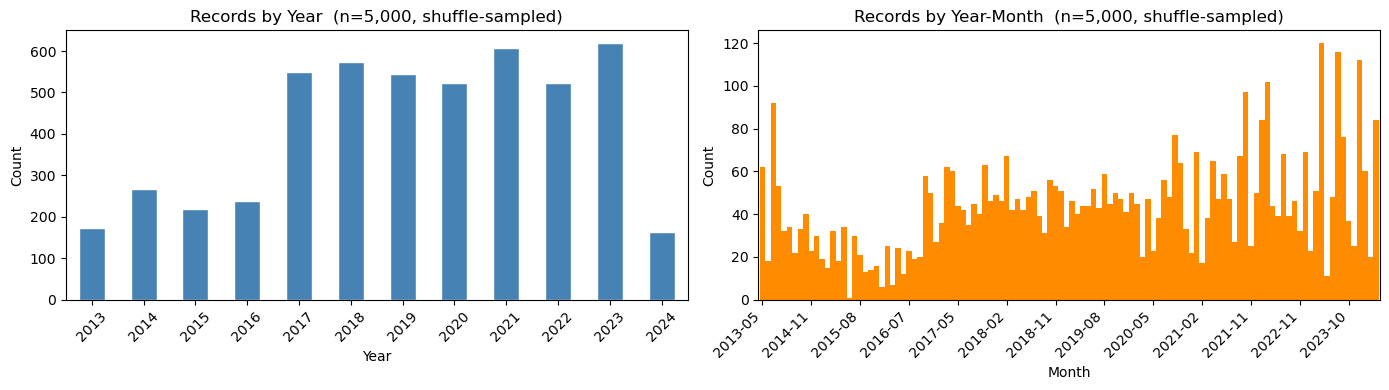

In [4]:
import random
import pandas as pd
import matplotlib.pyplot as plt

# fineweb_deduplicated is stored as a single file (no underlying Parquet shards),
# so .shard() falls back to record-level round-robin and would need to stream
# through the entire dataset for every virtual shard — far too slow.
# Instead, shuffle with a buffer (single pass) and take the desired count.
TOTAL_SAMPLE = 5_000
BUFFER_SIZE  = 10_000
SEED         = 42

shuffled_ds = fwd["train"].shuffle(buffer_size=BUFFER_SIZE, seed=SEED)

timestamps = []
for record in shuffled_ds.take(TOTAL_SAMPLE):
    ts = record.get("date")
    if ts:
        timestamps.append(ts)

print(f"Sampled {len(timestamps)} records")

# Parse timestamps (ISO format)
dates = pd.to_datetime(timestamps, utc=True)
s = pd.Series(dates)
by_year = s.dt.year.value_counts().sort_index()
by_ym   = s.dt.to_period("M").value_counts().sort_index()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

by_year.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Records by Year  (n={len(timestamps):,}, shuffle-sampled)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

by_ym_ts = by_ym.copy()
by_ym_ts.index = by_ym_ts.index.to_timestamp()
by_ym_ts.plot(kind="bar", ax=axes[1], color="darkorange", edgecolor="none", width=1.0)
axes[1].set_title(f"Records by Year-Month  (n={len(timestamps):,}, shuffle-sampled)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Count")
n_ticks = len(by_ym_ts)
step = max(1, n_ticks // 12)
axes[1].set_xticks(range(0, n_ticks, step))
axes[1].set_xticklabels(
    [f"{by_ym_ts.index[i].year}-{str(by_ym_ts.index[i].month).zfill(2)}"
     for i in range(0, n_ticks, step)],
    rotation=45, ha="right"
)

plt.tight_layout()
plt.show()

In [5]:
# Date range and distribution stats
print("=== Date Range ===")
print(f"  Earliest : {s.min()}")
print(f"  Latest   : {s.max()}")
print(f"  Span     : {s.max() - s.min()}")
print()
print("=== Distribution by Year ===")
for year, count in by_year.items():
    bar = "\u2588" * (count * 40 // by_year.max())
    print(f"  {year}  {count:>6}  {bar}")
print()
print("=== Distribution by Month (all years combined) ===")
by_month = s.dt.month.value_counts().sort_index()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for month, count in by_month.items():
    bar = "\u2588" * (count * 40 // by_month.max())
    print(f"  {month_names[month-1]}  {count:>6}  {bar}")

=== Date Range ===
  Earliest : 2013-05-18 05:25:26+00:00
  Latest   : 2024-04-25 12:01:29+00:00
  Span     : 3995 days 06:36:03

=== Distribution by Year ===
  2013     172  ███████████
  2014     267  █████████████████
  2015     219  ██████████████
  2016     238  ███████████████
  2017     549  ███████████████████████████████████
  2018     573  █████████████████████████████████████
  2019     545  ███████████████████████████████████
  2020     523  █████████████████████████████████
  2021     608  ███████████████████████████████████████
  2022     523  █████████████████████████████████
  2023     619  ████████████████████████████████████████
  2024     164  ██████████

=== Distribution by Month (all years combined) ===
  Jan     352  ████████████████████████
  Feb     362  █████████████████████████
  Mar     427  █████████████████████████████
  Apr     415  █████████████████████████████
  May     470  ████████████████████████████████
  Jun     430  ██████████████████████████████
 